In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
iva = 0.21

ventas_simuladas = {
    "Norte": {
        "Laptop": {"unidades": 32, "precio_unitario": 950.00},
        "Monitor": {"unidades": 18, "precio_unitario": 320.00},
    },
    "Sur": {
        "Teclado": {"unidades": 45, "precio_unitario": 75.00},
        "Impresora": {"unidades": 14, "precio_unitario": 220.00},
    },
    "Este": {
        "Mouse": {"unidades": 60, "precio_unitario": 30.00},
        "Camara": {"unidades": 9, "precio_unitario": 410.00},
    },
}

# Añadir el IVA a cada producto
for departamento, productos in ventas_simuladas.items():
    for producto, info in productos.items():
        info["iva"] = iva

print(ventas_simuladas)

{'Norte': {'Laptop': {'unidades': 32, 'precio_unitario': 950.0, 'iva': 0.21}, 'Monitor': {'unidades': 18, 'precio_unitario': 320.0, 'iva': 0.21}}, 'Sur': {'Teclado': {'unidades': 45, 'precio_unitario': 75.0, 'iva': 0.21}, 'Impresora': {'unidades': 14, 'precio_unitario': 220.0, 'iva': 0.21}}, 'Este': {'Mouse': {'unidades': 60, 'precio_unitario': 30.0, 'iva': 0.21}, 'Camara': {'unidades': 9, 'precio_unitario': 410.0, 'iva': 0.21}}}


In [3]:
df = pd.DataFrame(
    [
        {
            "Departamento": departamento,
            "Producto": producto,
            "Unidades": info["unidades"],
            "Precio_Unitario": info["precio_unitario"],
            "IVA": info["iva"],
        }
        for departamento, productos in ventas_simuladas.items()
        for producto, info in productos.items()
    ]
)

df

,Departamento,Producto,Unidades,Precio_Unitario,IVA
0,Norte,Laptop,32,950.0,0.21
1,Norte,Monitor,18,320.0,0.21
2,Sur,Teclado,45,75.0,0.21
3,Sur,Impresora,14,220.0,0.21
4,Este,Mouse,60,30.0,0.21
5,Este,Camara,9,410.0,0.21


In [4]:
df.describe(include="all")

,Departamento,Producto,Unidades,Precio_Unitario,IVA
count,6,6,6.000000,6.000000,6.00
unique,3,6,NaN,NaN,NaN
top,Norte,Laptop,NaN,NaN,NaN
freq,2,1,NaN,NaN,NaN
mean,NaN,NaN,29.666667,334.166667,0.21
std,NaN,NaN,19.846074,334.042163,0.00
min,NaN,NaN,9.000000,30.000000,0.21
25%,NaN,NaN,15.000000,111.250000,0.21
50%,NaN,NaN,25.000000,270.000000,0.21
75%,NaN,NaN,41.750000,387.500000,0.21


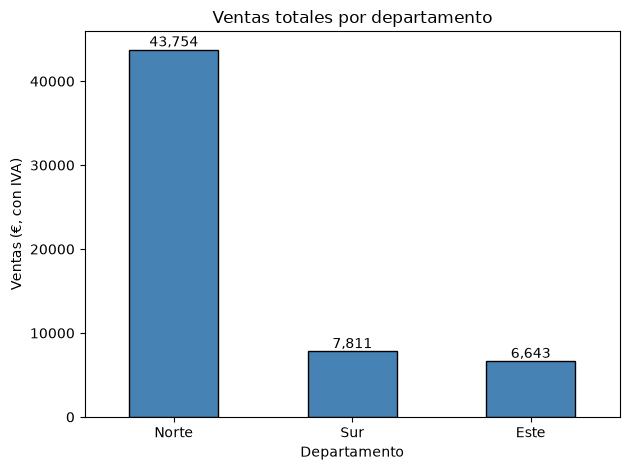

In [5]:
# Ventas totales (con IVA) por departamento
df["Total_con_IVA"] = df["Unidades"] * df["Precio_Unitario"] * (1 + df["IVA"])

ventas_departamento = df.groupby("Departamento")["Total_con_IVA"].sum().sort_values(ascending=False)

ax = ventas_departamento.plot(kind="bar", color="steelblue", edgecolor="black")
ax.set_title("Ventas totales por departamento")
ax.set_xlabel("Departamento")
ax.set_ylabel("Ventas (€, con IVA)")
plt.xticks(rotation=0)

# Etiquetas de valor encima de cada barra
for i, v in enumerate(ventas_departamento):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## Ingresos por producto y departamento

Gráfico de barras horizontales con paleta apta para daltonismo (Okabe-Ito), etiquetas de valor directas y estilo minimalista.

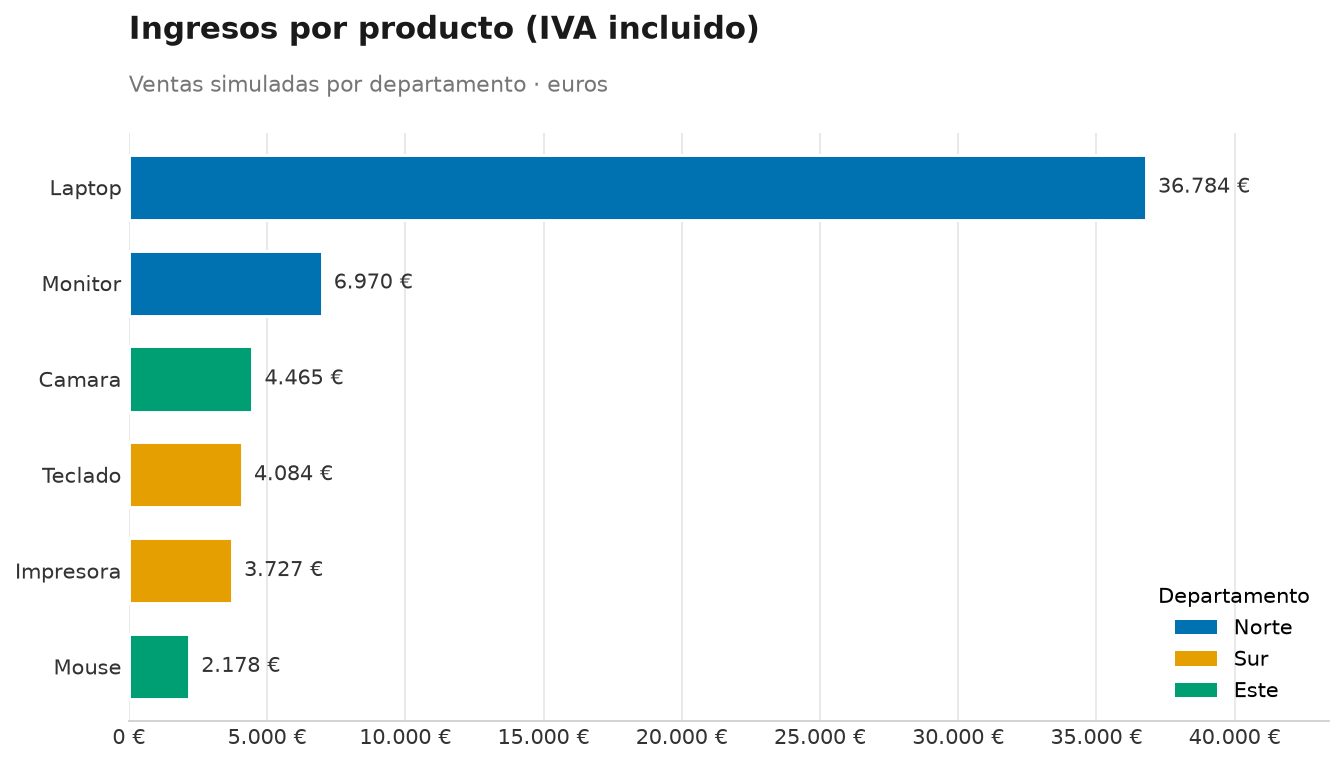

In [6]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

# --- Datos para el gráfico ---
plot_df = df.sort_values("Total_con_IVA").reset_index(drop=True)
dept_colors = {"Norte": "#0072B2", "Sur": "#E69F00", "Este": "#009E73"}
bar_colors = plot_df["Departamento"].map(dept_colors)
vmax = plot_df["Total_con_IVA"].max()

eur = lambda v: f"{v:,.0f} €".replace(",", ".")

# --- Figura ---
fig, ax = plt.subplots(figsize=(10, 5.6), dpi=150)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
fig.subplots_adjust(top=0.80, left=0.14, right=0.94, bottom=0.10)

bars = ax.barh(plot_df["Producto"], plot_df["Total_con_IVA"],
               color=bar_colors, edgecolor="white", linewidth=1.4,
               height=0.68, zorder=3)

for bar, val in zip(bars, plot_df["Total_con_IVA"]):
    ax.text(bar.get_width() + vmax * 0.012, bar.get_y() + bar.get_height() / 2,
            eur(val), va="center", ha="left", fontsize=10, color="#333333")

# --- Ejes y rejilla ---
ax.set_xlim(0, vmax * 1.18)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: eur(x)))
ax.grid(axis="x", color="#E9E9E9", linewidth=1, zorder=0)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(length=0, labelsize=10, colors="#333333")
ax.margins(y=0.04)

# --- Títulos (fuera del área de datos) ---
ax.text(0, 1.16, "Ingresos por producto (IVA incluido)", transform=ax.transAxes,
        fontsize=15, fontweight="bold", color="#1A1A1A")
ax.text(0, 1.07, "Ventas simuladas por departamento · euros", transform=ax.transAxes,
        fontsize=10.5, color="#767676")

# --- Leyenda ---
handles = [Patch(facecolor=c, label=d) for d, c in dept_colors.items()]
ax.legend(handles=handles, title="Departamento", loc="lower right",
          frameon=False, fontsize=10, title_fontsize=10)

os.makedirs("../outputs", exist_ok=True)
plt.savefig("../outputs/ingresos_por_producto.png", dpi=150, bbox_inches="tight")
plt.show()


## Función `calcular_total_venta`

Calcula el importe total de una venta (IVA incluido). Acepta valores sueltos, una entrada del diccionario `ventas_simuladas` o una fila del DataFrame.

In [7]:
def calcular_total_venta(venta=None, *, unidades=None, precio_unitario=None, iva=0.21):
    """Importe total de una venta con IVA incluido: unidades * precio_unitario * (1 + iva).

    Uso:
      calcular_total_venta(unidades=32, precio_unitario=950, iva=0.21)
      calcular_total_venta(ventas_simuladas["Norte"]["Laptop"])   # dict
      calcular_total_venta(df.loc[0])                              # fila del DataFrame
    """
    if venta is not None:
        get = venta.get if hasattr(venta, "get") else venta.__getitem__
        unidades = get("unidades") if "unidades" in venta else get("Unidades")
        precio_unitario = get("precio_unitario") if "precio_unitario" in venta else get("Precio_Unitario")
        if "iva" in venta:
            iva = get("iva")
        elif "IVA" in venta:
            iva = get("IVA")

    if unidades is None or precio_unitario is None:
        raise ValueError("Faltan 'unidades' y/o 'precio_unitario'.")

    return round(unidades * precio_unitario * (1 + iva), 2)


# 1) Con valores sueltos
print("Suelto :", calcular_total_venta(unidades=32, precio_unitario=950.0, iva=0.21))

# 2) Con una entrada del diccionario
print("Dict   :", calcular_total_venta(ventas_simuladas["Norte"]["Laptop"]))

# 3) Con el DataFrame (nueva columna) y verificación frente a Total_con_IVA
df["Total_venta"] = df.apply(calcular_total_venta, axis=1)
print(df[["Departamento", "Producto", "Total_con_IVA", "Total_venta"]])
print("Coincide con Total_con_IVA:",
      bool((df["Total_venta"] == df["Total_con_IVA"].round(2)).all()))


Suelto : 36784.0
Dict   : 36784.0
  Departamento   Producto  Total_con_IVA  Total_venta
0        Norte     Laptop       36784.00     36784.00
1        Norte    Monitor        6969.60      6969.60
2          Sur    Teclado        4083.75      4083.75
3          Sur  Impresora        3726.80      3726.80
4         Este      Mouse        2178.00      2178.00
5         Este     Camara        4464.90      4464.90
Coincide con Total_con_IVA: True
